<center><image src="https://drive.google.com/uc?id=1n3G4TdK_u6PQHcLrxB_A0HijNdigXmUH">

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Классификация звуков</b></h3>

**Автор**: Ермекова Асель


В этом задании вам предстоит решить задачу классификации звуков на основе wav файлов и использовании различных аугментаций данных.

Есть две части этого домашнего задания.

### 1 Часть. Отправить ваши предсказания в Stepik.
Результат вашей лучшей модели будет оцениваться на тестовой выборке по метрике Accuracy. Эта часть оценивается до 5 баллов.

1) $1.00 \geqslant score \geqslant 0.75$ --- 5 баллов

2) $0.75 > score \geqslant 0.70$ --- 4 балла

3) $0.70 > score \geqslant 0.60$ --- 3 балла

4) $0.60 > score \geqslant 0.50$ --- 2 балла

5) $0.50 > score \geqslant 0.25$ --- 1 балл

6) $0.25 > score$ --- 0 баллов

Для этого мы предварительно разделили данные в задании на три части.

1. `train.csv`. На этом наборе данных вам необходимо создать и обучить модель.
2. `valid.csv`. На этом наборе данных вы можете валидировать вашу модель.
3. `test.csv`. Предсказания для этого набора необходимо записать в файл `submission.csv` и сдать в соответствующий шаг на Stepik. Количество попыток ограничено до 100 штук. В конце ноутбука есть пример оформления файла посылки.

### 2 Часть. Сделать полноценный отчет о вашей работе (5 баллов).
Опишите итеративный процесс улучшения метрики:
* как вы обработали данные, какие аугментации добавляли, что сработало, а что нет.
* какие архитектуры модели попробовали и какие результаты получились.

В этом пункте вам необходимо отправить файл в формате .ipynb на Stepik --- для этого в домашнем задании есть отдельный шаг. Этот пункт оценивается до 5 баллов.

### Peer-review
Вторая часть будет проверяться в формате peer-review, т.е. вашу посылку на Stepik будут проверять 3 других студента, и медианное значение их оценок будет выставлено. Чтобы получить баллы, вам также нужно будет проверить трех других учеников. Это станет доступно после того, как вы сдадите задание сами.


### Несколько замечаний по выполнению работы
* Во всех пунктах указания это минимальный набор вещей, которые стоит сделать. Если вы можете сделать какой-то шаг лучше или добавить что-то свое --- дерзайте!
* Пожалуйста, перед сдачей ноутбука убедитесь, что работа чистая и понятная. Это значительно облегчит проверку и повысит ваши ожидаемые баллы.
* Если у вас будут проблемы с решением или хочется совета, то пишите в наш чат в телеграме.


# **Environmental Sound Classification**

## **Task Overview**

В этом домашнем задании вам предстоит работать с датасетом различных звуков окружающей среды (собака, дождь, плач ребёнка и т. д.).

### **Part 1: Create Dataset**

Первым делом давайте скачаем датасет и прилагающие csv файлы с метками класса.

Разархивируйте zip файл, где содержатся wav файлы датасета.

In [48]:
import pandas as pd
import librosa
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio
import warnings
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
warnings.filterwarnings("ignore")

In [49]:
train_df = pd.read_csv("train.csv")
valid_df = pd.read_csv("valid.csv")
test_df = pd.read_csv("test.csv")

Для этого задания при создании датасета вам нужно сделать обработку аудио данных следующим образом:
* **Sample rate --> 16000**: ресэмплируйте оригинальный `sample_rate` в `sample_rate = 16000`
* **Stereo --> Mono**: преобразуйте многоканальное аудио в моноканальное
* **Length = X secs:** чтобы суметь создать батч, вам необходимо, чтобы длина всех ваших аудиозаписей была одинаковой, поэтому вам нужно зафиксировать длину всех аудиозаписей, и если аудио меньше заданной длины, то сделайте паддинг, если больше, обрежьте аудио до заданной длины.

* **Audio Augmentation:** используйте разные аугментации. Вы можете воспользоваться библиотеками:
  * [torchaudio.transforms](https://docs.pytorch.org/audio/main/transforms.html)
  * [torch_audiomentations](https://github.com/iver56/torch-audiomentations)

**ВАЖНО**: в этом домашнем задании вам нельзя переводить `wav` в мелспектрограммы.

Внизу для удобства предоставлен псевдокод, который можно заполнить необходимыми функциями, но вы можете видоизменять его как вам будет удобно.

In [50]:
import torch.nn as nn
import torchaudio
import torch
from torch.utils.data import Dataset
import pandas as pd
import os
import random

class SimpleAudioDataset(Dataset):
    """A dataset to load, preprocess, and augment audio files."""

    def __init__(self, dataframe, audio_dir=None, target_length_sec=5, 
                 sample_rate=16000, do_augmentation=False):

        self.dataframe = dataframe.reset_index(drop=True)
        self.audio_dir = audio_dir
        self.target_length_sec = target_length_sec
        self.target_sample_rate = sample_rate
        self.do_augmentation = do_augmentation
        self.target_length_samples  = target_length_sec * sample_rate
        
        if 'category' in self.dataframe.columns:
            self.label_column = 'category'
        elif 'label' in self.dataframe.columns:
            self.label_column = 'label'
        else:
            self.label_column = self.dataframe.columns[1]

        self.categories = self.dataframe[self.label_column].unique()
        self.num_classes = len(self.categories)

        self.category_to_idx = {category: idx for idx, category in enumerate(sorted(self.categories))}
        self.idx_to_category = {idx: category for category, idx in self.category_to_idx.items()}
                
        self.classes = list(self.idx_to_category.values())
        
        if self.do_augmentation:
            self.augmentations = [
                torchaudio.transforms.Vol(gain=0.2),
                torchaudio.transforms.SpeedPerturbation(self.target_sample_rate, [0.9, 1.1])
            ]
            
    def __len__(self):
        return len(self.dataframe) 

    def __getitem__(self, index):
        # 1. Get the file path and label
        row = self.dataframe.iloc[index]
        audio_file_path = row['filename'] # here is your code
        label = row[self.label_column] # here is your code
        
        if self.audio_dir and not os.path.isabs(audio_file_path):
            audio_file_path = os.path.join(self.audio_dir, audio_file_path)
        # 2. LOAD: Load the raw audio file
        try:
            signal, sample_rate = torchaudio.load(audio_file_path)

        except Exception as e:
            print(f"Error loading audio file: {audio_file_path}")
            print(f"Error: {e}")
            signal = torch.zeros(1, self.target_length_samples)
            sample_rate = self.target_sample_rate
            label = -1
            return signal.squeeze(0), label
        

        # 3. PREPROCESS: Apply the preprocessing steps
        signal = self._resample(signal, sample_rate) # Resample to the sample rate 16000
        signal = self._stereo_to_mono(signal) # Converts (channels, samples) -> (samples,)
        signal = self._cut_or_pad(signal) # State fixed length

        # 4. AUGMENT: Apply augmentations only if training
        if self.do_augmentation:
            signal = self._augmentation(signal)
        label = self.category_to_idx[label]
        signal = signal.squeeze(0)

        # 5. RETURN: We now have a clean, standardized waveform and its label
        return signal, label

    # --- The Core Preprocessing Functions ---
    def _resample(self, signal, original_sr):
        if original_sr != self.target_sample_rate:
            resampler = torchaudio.transforms.Resample(
                orig_freq=original_sr, 
                new_freq=self.target_sample_rate
            )
            signal = resampler(signal)
        return signal

    def _stereo_to_mono(self, signal):
        # here is your code
        if signal.shape[0] > 1:
            signal = torch.mean(signal, dim=0, keepdim=True)
        return signal

    def _cut_or_pad(self, signal):
        # here is your code
        current_length = signal.shape[1]
        target_length = self.target_length_samples
        if current_length < target_length:
            padding = target_length - current_length
            signal = torch.nn.functional.pad(signal, (0, padding))

        elif current_length > target_length:
            start = (current_length - target_length) // 2
            signal = signal[:, start:start + target_length]
        return signal

    def _augmentation(self, signal):

        if random.random() > 0.5:
            gain = random.uniform(0.7, 1.3)
            signal = signal * gain

        if random.random() > 0.7:
            noise = torch.randn_like(signal) * 0.01
            signal = signal + noise
            
        return signal


In [51]:
train_dataset = SimpleAudioDataset(train_df, target_length_sec=5, sample_rate=16000, do_augmentation=True)
valid_dataset = SimpleAudioDataset(valid_df, target_length_sec=5, sample_rate=16000, do_augmentation=False)

### **Part 2: Building a Model that Learns from Waveforms**

В этом разделе вам нужно написать архитектуру по вашему выбору, которая будет решать задачу классификации на 5 классов.

In [52]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [53]:
class SoundClassificationModel(nn.Module):
    """A simple model that processes raw waveforms."""

    def __init__(self, input_size=80000, num_classes=5):
        super().__init__()
        
        self.conv_layers = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=64, stride=4, padding=32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(4),  
            nn.Conv1d(32, 64, kernel_size=32, stride=2, padding=16), 
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(4),  
            nn.Conv1d(64, 128, kernel_size=16, stride=2, padding=8),  
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(4), 
            nn.Conv1d(128, 256, kernel_size=8, stride=2, padding=4), 
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.MaxPool1d(4), 
        )
        
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),  
            nn.Flatten(), 
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)  
        )

    def forward(self, x):
        x = x.unsqueeze(1)  
        x = self.conv_layers(x)
        x = self.classifier(x)
        return x



### **Part 3: Training and Evaluation**

В этом разделе вам нужно написать код тренировки и запустить саму тренировку и вывести лучшие значения метрики качества на train и valid данных. Для вашего удобства написана функция отображения значений лоссов и метрики accuracy.

In [54]:
def plot_metrics(train_losses, train_accuracies, test_losses, test_accuracies):
    """
    Plot training and validation metrics
    """
    epochs = range(1, len(train_losses) + 1)

    # Create subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot loss
    ax1.plot(epochs, train_losses, 'b-', label='Training Loss', linewidth=2)
    ax1.plot(epochs, test_losses, 'r-', label='Test Loss', linewidth=2)
    ax1.set_title('Training and Test Loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot accuracy
    ax2.plot(epochs, train_accuracies, 'b-', label='Training Accuracy', linewidth=2)
    ax2.plot(epochs, test_accuracies, 'r-', label='Valid Accuracy', linewidth=2)
    ax2.set_title('Training and Valid Accuracy')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Adjust layout and display
    plt.tight_layout()
    plt.show()


In [55]:
def calculate_accuracy(predictions, labels):
    _, predicted = torch.max(predictions, 1)
    correct = (predicted == labels).sum().item()
    total = labels.size(0)
    return correct / total


Using device: cuda
Epoch 1/10:
Train Loss: 1.4447, Train Acc: 0.4500
Valid Loss: 1.6952, Valid Acc: 0.2000
--------------------------------------------------


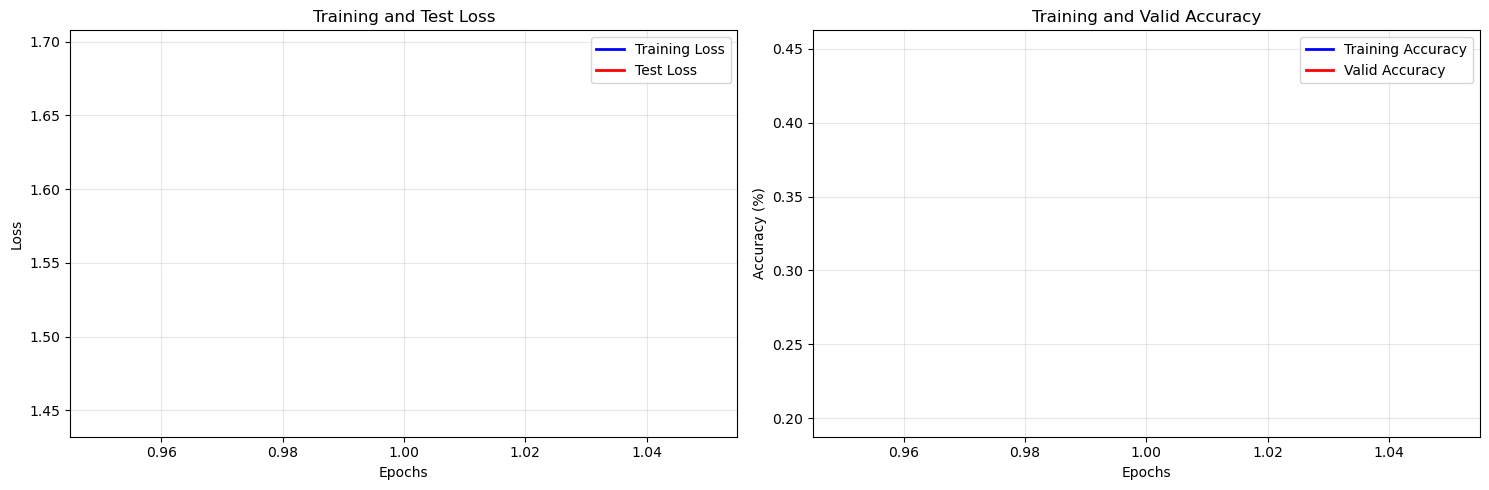

Epoch 2/10:
Train Loss: 1.5052, Train Acc: 0.4167
Valid Loss: 1.8018, Valid Acc: 0.2000
--------------------------------------------------


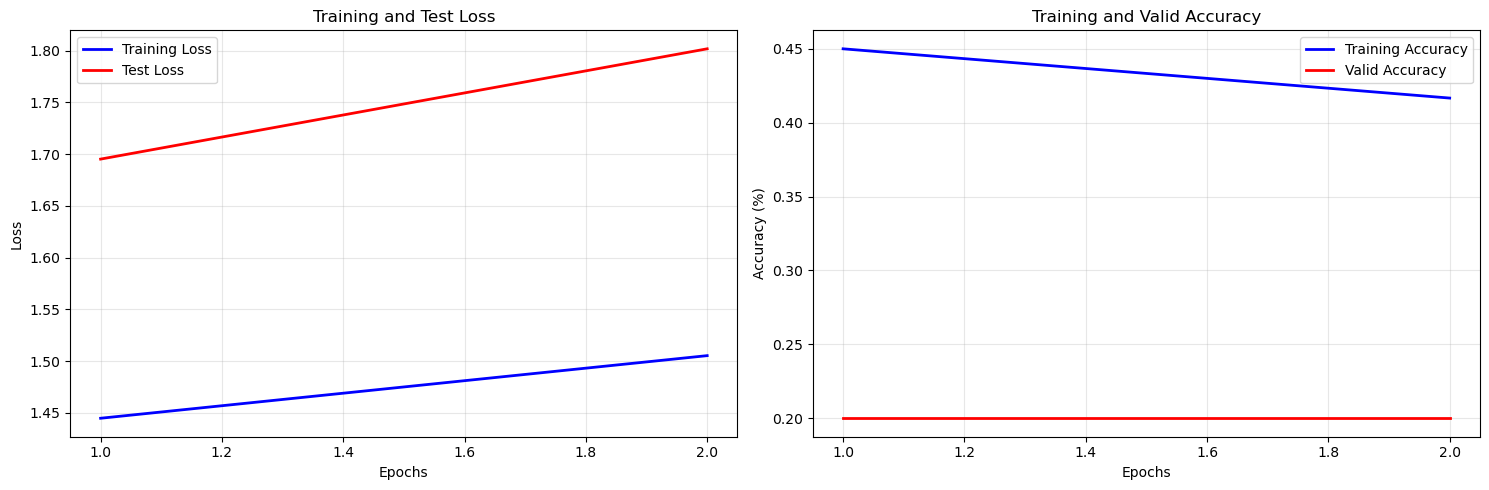

Epoch 3/10:
Train Loss: 1.2694, Train Acc: 0.4833
Valid Loss: 1.6422, Valid Acc: 0.2750
--------------------------------------------------


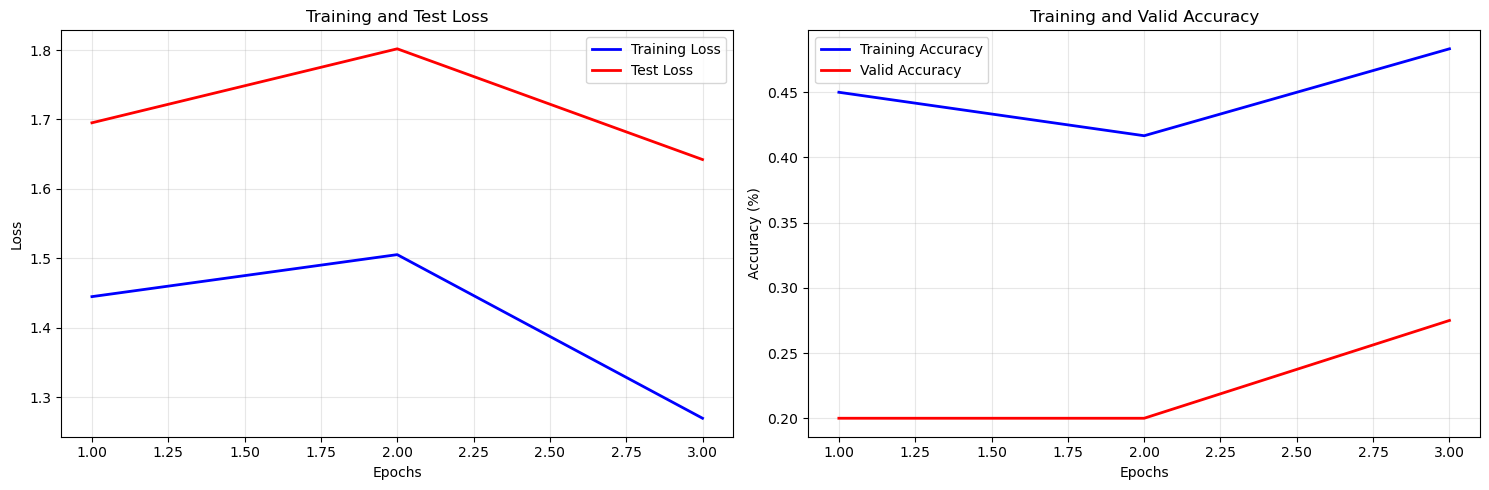

Epoch 4/10:
Train Loss: 1.0189, Train Acc: 0.6500
Valid Loss: 1.3051, Valid Acc: 0.6250
--------------------------------------------------


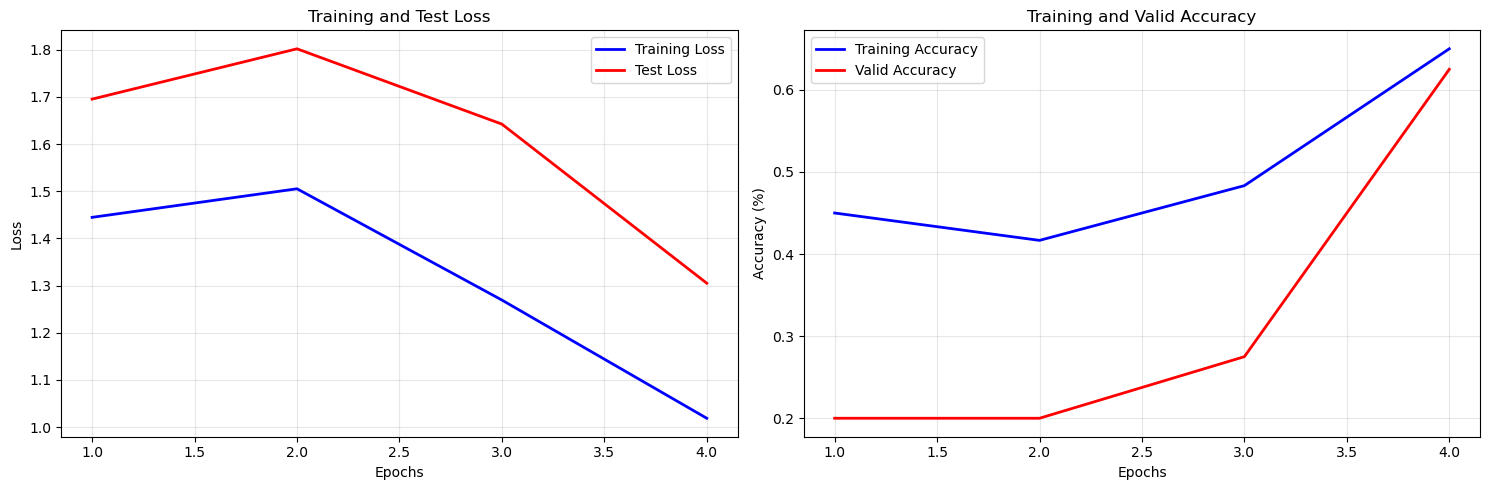

Epoch 5/10:
Train Loss: 1.4485, Train Acc: 0.5417
Valid Loss: 1.2008, Valid Acc: 0.6250
--------------------------------------------------


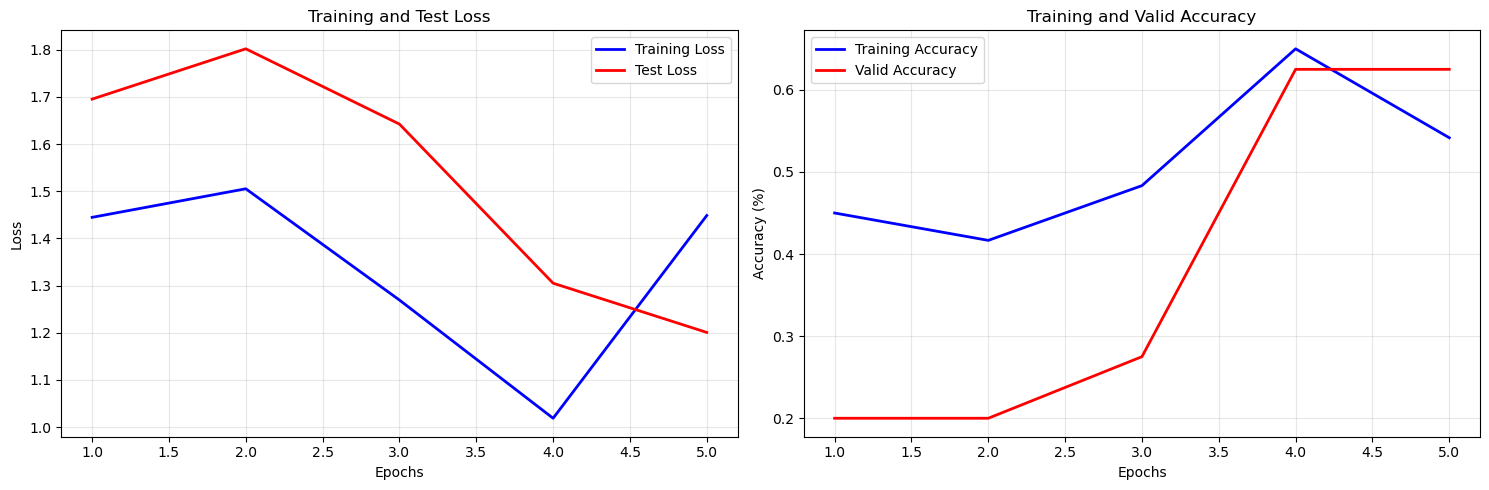

Epoch 6/10:
Train Loss: 1.1504, Train Acc: 0.6000
Valid Loss: 1.0701, Valid Acc: 0.7000
--------------------------------------------------


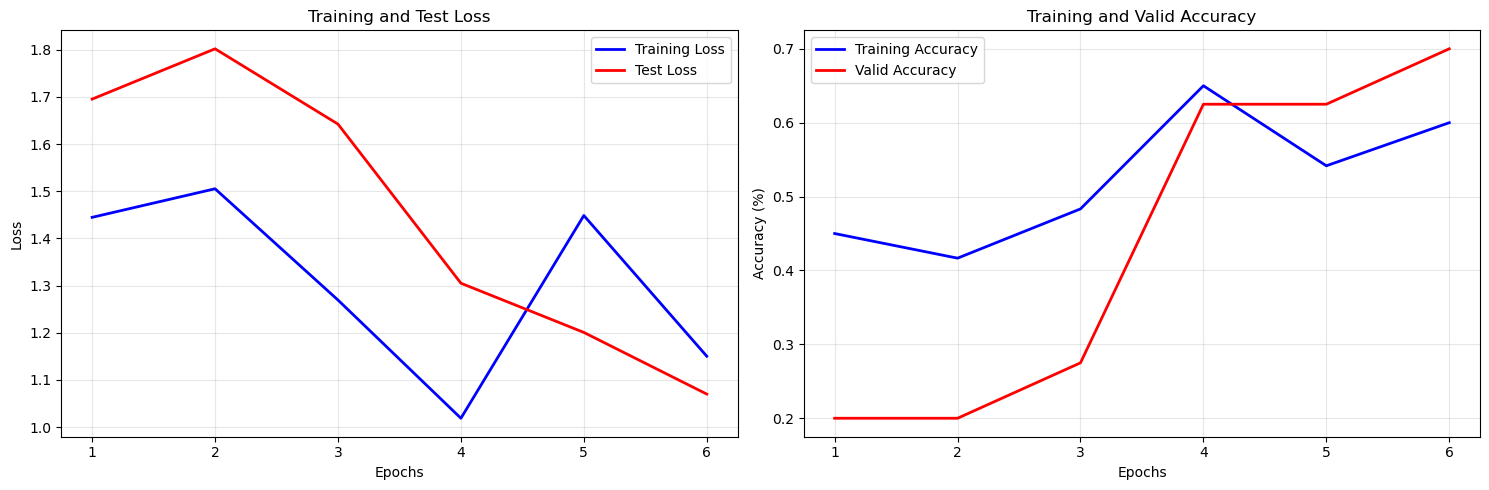

Epoch 7/10:
Train Loss: 1.3621, Train Acc: 0.5417
Valid Loss: 1.1085, Valid Acc: 0.7500
--------------------------------------------------


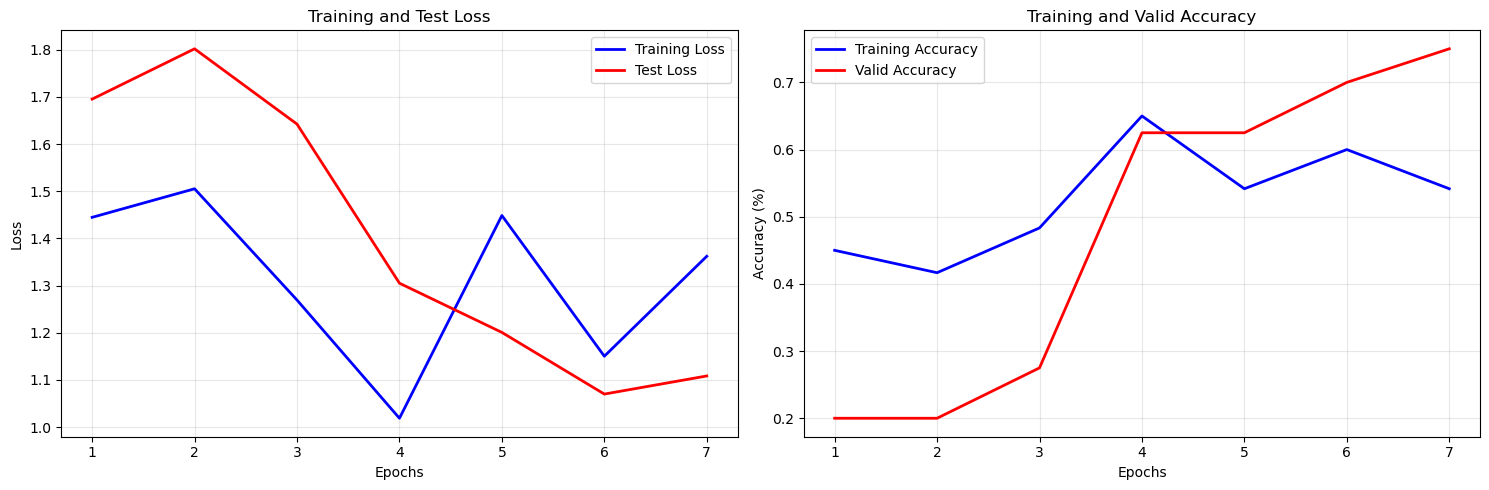

Epoch 8/10:
Train Loss: 1.6063, Train Acc: 0.4333
Valid Loss: 1.1287, Valid Acc: 0.6250
--------------------------------------------------


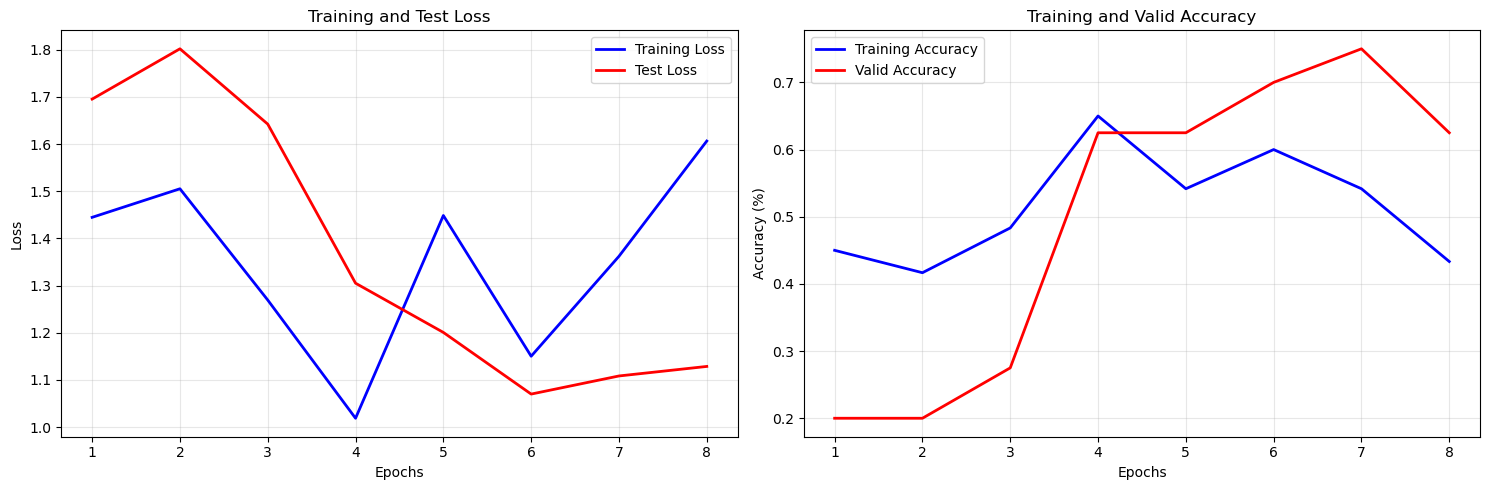

Epoch 9/10:
Train Loss: 1.3309, Train Acc: 0.4750
Valid Loss: 1.0862, Valid Acc: 0.7250
--------------------------------------------------


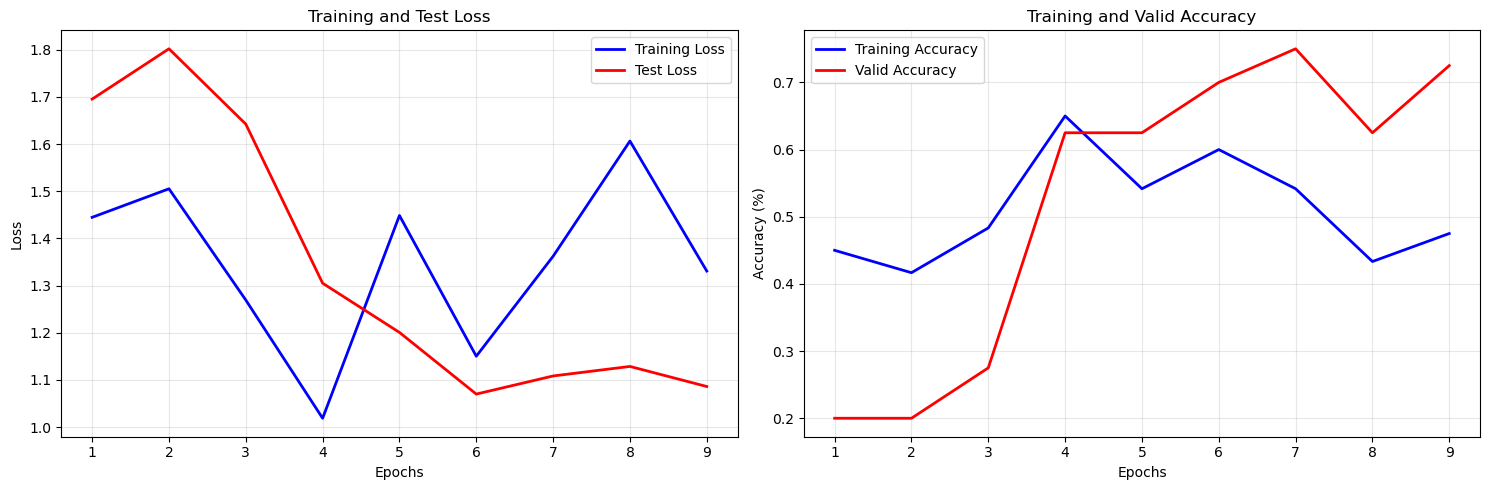

Epoch 10/10:
Train Loss: 1.2991, Train Acc: 0.5500
Valid Loss: 1.0107, Valid Acc: 0.7500
--------------------------------------------------


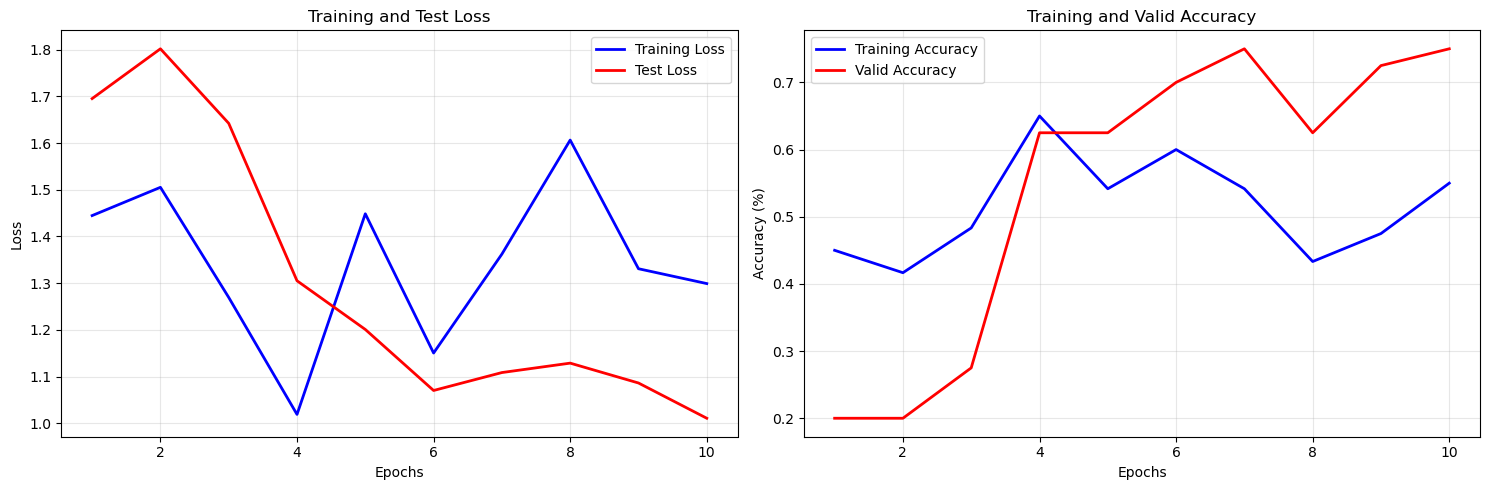

Обучение завершено!


In [56]:
from torch.utils.data import DataLoader
from IPython.display import clear_output
dir = "D:\Projects\DeepLearningSound\sound_classification_dataset"

train_data = SimpleAudioDataset(train_df, audio_dir=dir, target_length_sec=5, 
                                sample_rate=16000, do_augmentation=True) 
valid_data = SimpleAudioDataset(valid_df, audio_dir=dir, target_length_sec=5,
                                sample_rate=16000, do_augmentation=False) 

train_loader = DataLoader(train_data, batch_size=8, shuffle=True, num_workers=0)
valid_loader = DataLoader(valid_data, batch_size=8, shuffle=False, num_workers=0)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

model = SoundClassificationModel(input_size=80000, num_classes=5).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_losses = []
train_accuracies = []
valid_losses = []
valid_accuracies = []

n_epochs = 10

for epoch in range(n_epochs):
    model.train()
    train_loss = 0.0
    train_accuracy = 0.0
    train_batches = 0

    for signals, labels in train_loader:
        signals, labels = signals.to(device), labels.to(device)
    
        valid_mask = labels != -1
        if valid_mask.sum() == 0:
            continue
            
        signals = signals[valid_mask]
        labels = labels[valid_mask]
    
        if labels.min() > 0:
            labels = labels - 1

        optimizer.zero_grad() 
        predictions = model(signals)
        loss = criterion(predictions, labels)
        accuracy = calculate_accuracy(predictions, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        train_loss += loss.item()
        train_accuracy += accuracy
        train_batches += 1


    model.eval()
    valid_loss = 0.0
    valid_accuracy = 0.0
    valid_batches = 0
    
    with torch.no_grad():
        for signals, labels in valid_loader:
            signals, labels = signals.to(device), labels.to(device)
            
            valid_mask = labels != -1
            if valid_mask.sum() == 0:
                continue
                
            signals = signals[valid_mask]
            labels = labels[valid_mask]
            
            if labels.min() > 0:
                labels = labels - 1
            
            predictions = model(signals)
            loss = criterion(predictions, labels)
            accuracy = calculate_accuracy(predictions, labels)

            valid_loss += loss.item()
            valid_accuracy += accuracy
            valid_batches += 1

    if train_batches > 0 and valid_batches > 0:
        epoch_train_loss = train_loss / train_batches
        epoch_train_acc = train_accuracy / train_batches
        epoch_valid_loss = valid_loss / valid_batches
        epoch_valid_acc = valid_accuracy / valid_batches

        train_losses.append(epoch_train_loss)
        train_accuracies.append(epoch_train_acc)
        valid_losses.append(epoch_valid_loss)
        valid_accuracies.append(epoch_valid_acc)

        print(f'Epoch {epoch+1}/{n_epochs}:')
        print(f'Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f}')
        print(f'Valid Loss: {epoch_valid_loss:.4f}, Valid Acc: {epoch_valid_acc:.4f}')
        print('-' * 50)

    plot_metrics(train_losses, train_accuracies, valid_losses, valid_accuracies)

print("Обучение завершено!")

In [57]:
print("Train Accuracy = ", train_accuracies[-1])
print("Valid Accuracy = ", valid_accuracies[-1])

Train Accuracy =  0.55
Valid Accuracy =  0.75


### **Part 4. Test Demo for ESC-50**

Для вашего удобства предоставляется код для тестирования модели и отрисовки формы сигналов, прогноза и топ-5 наиболее вероятных классов.

Using device: cuda
ESC-50 Audio Classification Demo!
Error loading audio file: 4-161127-A-10.wav
Error: Failed to open the input "4-161127-A-10.wav" (No such file or directory).


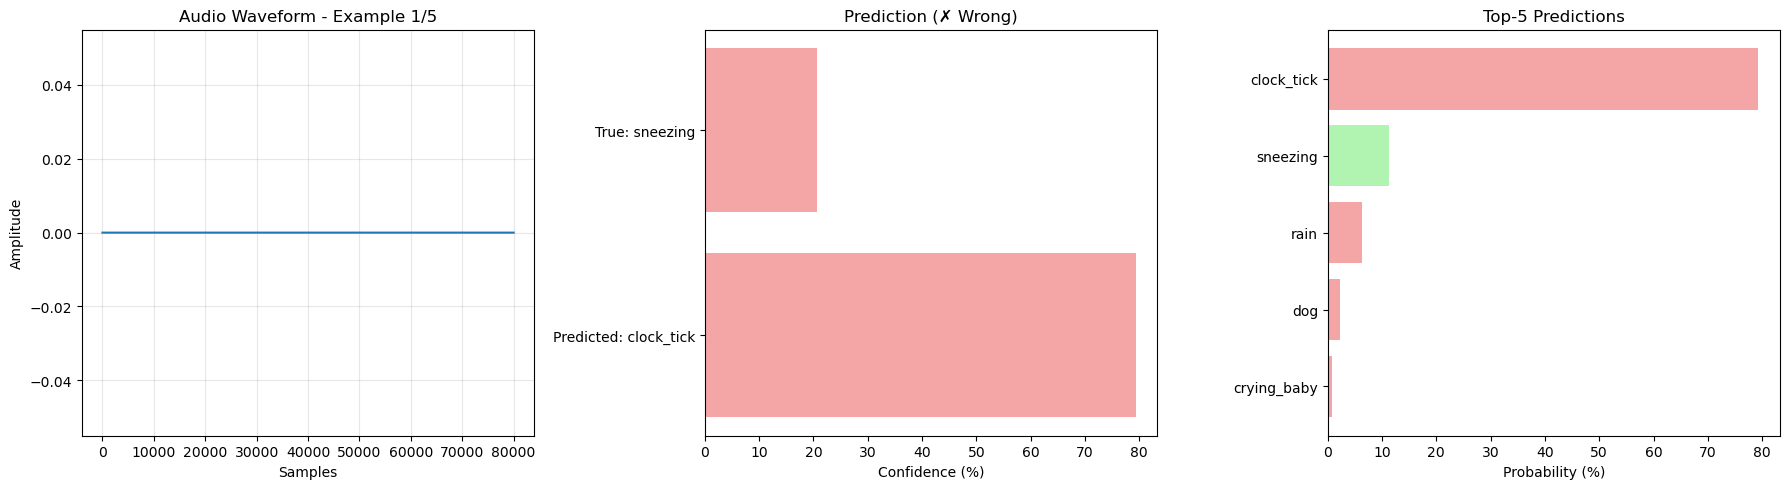

Playing: sneezing


Prediction: clock_tick (79.32%)
True label: sneezing
Correct: False
Error loading audio file: 4-199261-A-0.wav
Error: Failed to open the input "4-199261-A-0.wav" (No such file or directory).


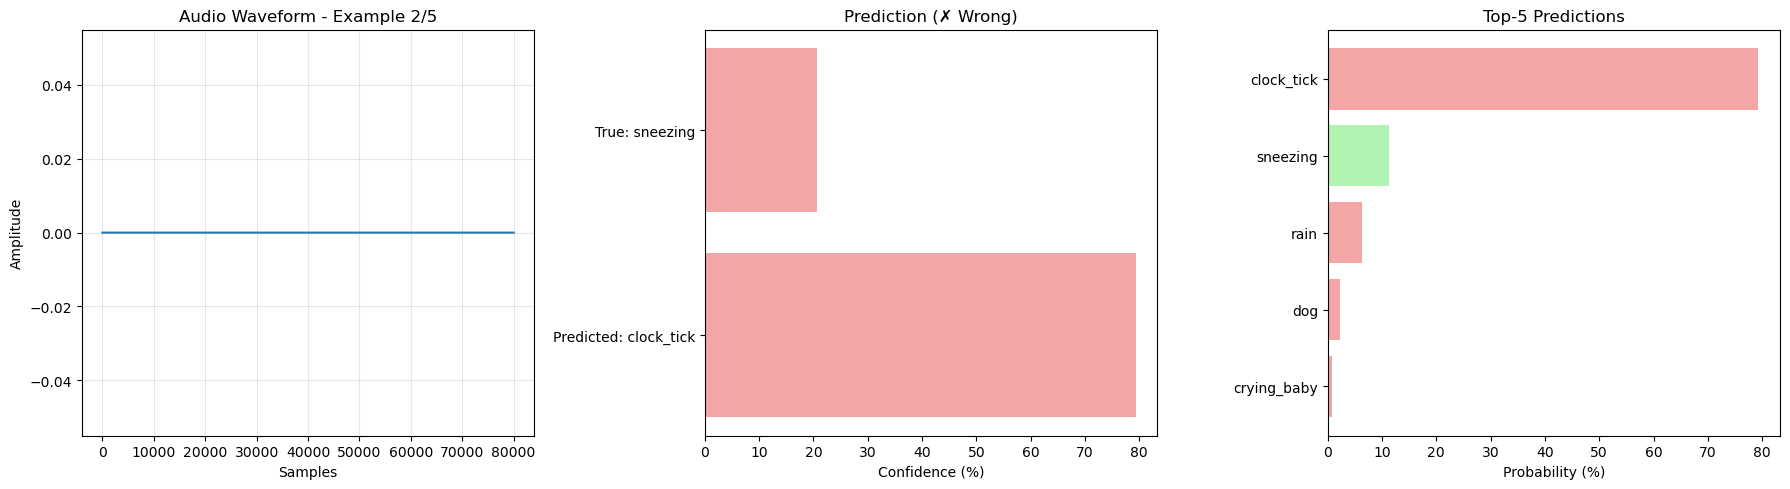

Playing: sneezing


Prediction: clock_tick (79.32%)
True label: sneezing
Correct: False
Error loading audio file: 4-180380-A-10.wav
Error: Failed to open the input "4-180380-A-10.wav" (No such file or directory).


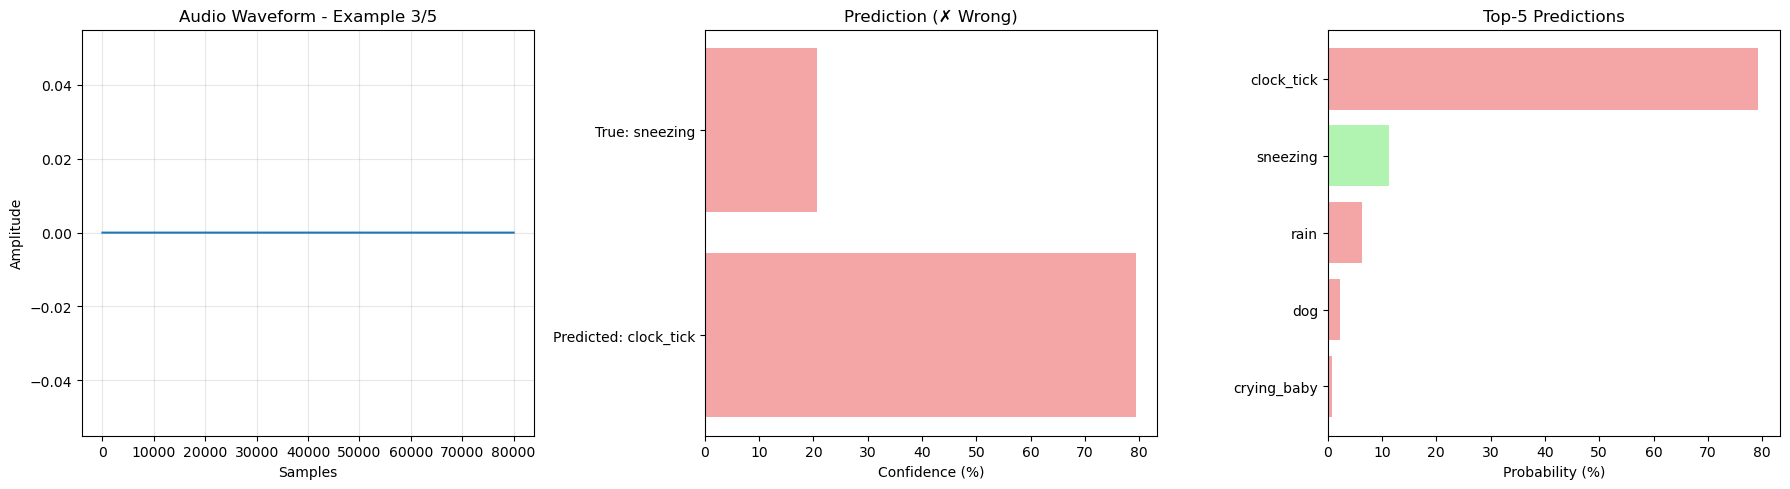

Playing: sneezing


Prediction: clock_tick (79.32%)
True label: sneezing
Correct: False
Error loading audio file: 4-167077-B-20.wav
Error: Failed to open the input "4-167077-B-20.wav" (No such file or directory).


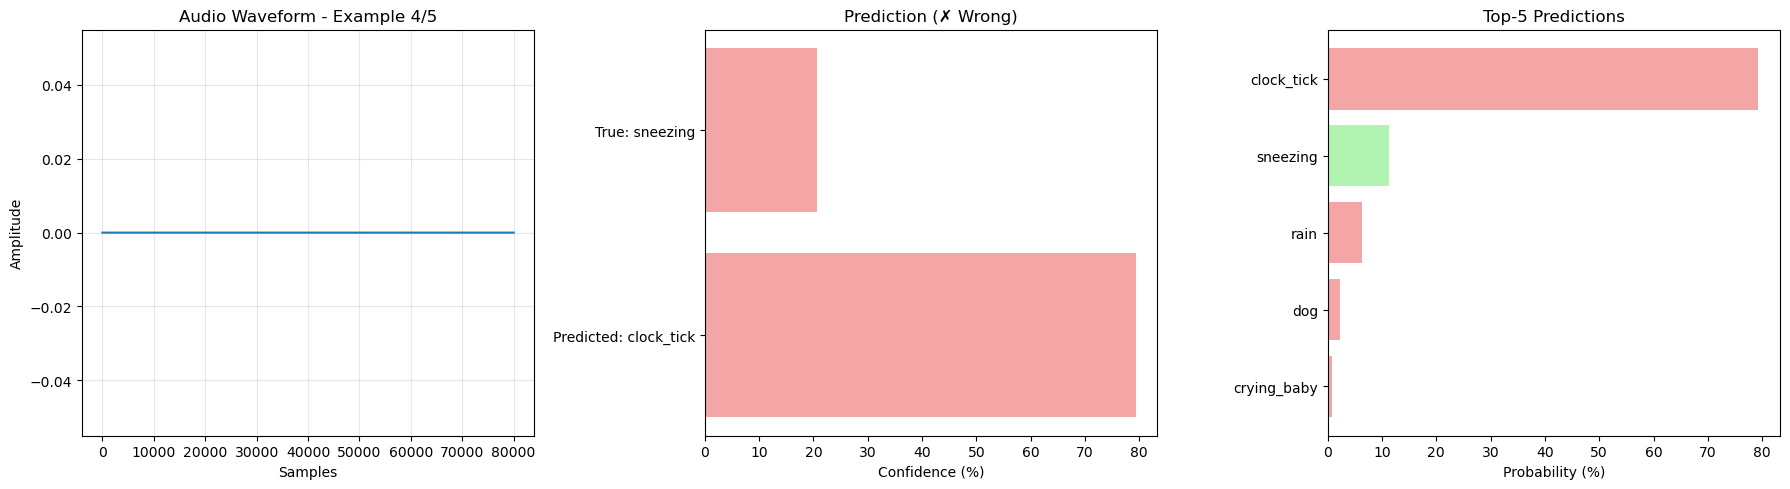

Playing: sneezing


Prediction: clock_tick (79.32%)
True label: sneezing
Correct: False
Error loading audio file: 4-179984-A-38.wav
Error: Failed to open the input "4-179984-A-38.wav" (No such file or directory).


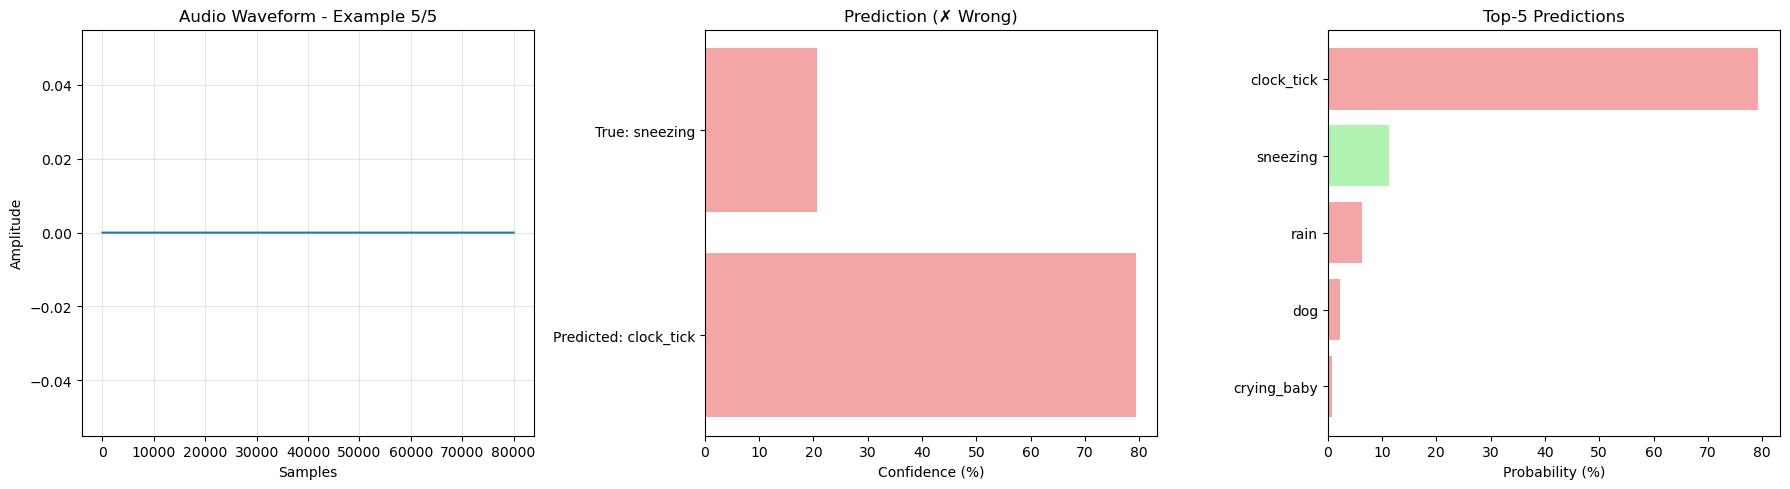

Playing: sneezing


Prediction: clock_tick (79.32%)
True label: sneezing
Correct: False
Error loading audio file: 4-156843-A-21.wav
Error: Failed to open the input "4-156843-A-21.wav" (No such file or directory).
Error loading audio file: 4-156844-A-21.wav
Error: Failed to open the input "4-156844-A-21.wav" (No such file or directory).
Error loading audio file: 4-157297-A-21.wav
Error: Failed to open the input "4-157297-A-21.wav" (No such file or directory).
Error loading audio file: 4-160999-A-10.wav
Error: Failed to open the input "4-160999-A-10.wav" (No such file or directory).
Error loading audio file: 4-161127-A-10.wav
Error: Failed to open the input "4-161127-A-10.wav" (No such file or directory).
Error loading audio file: 4-163264-A-10.wav
Error: Failed to open the input "4-163264-A-10.wav" (No such file or directory).
Error loading audio file: 4-164206-A-10.wav
Error: Failed to open the input "4-164206-A-10.wav" (No such file or directory).
Error loading audio file: 4-166661-A-10.wav
Error: Failed

In [58]:
class ESC50TestDemo:
    def __init__(self, model, test_dataset, device):
        self.model = model
        self.test_dataset = test_dataset
        self.device = device
        self.classes = test_dataset.classes
        self.model.eval()  # Set to evaluation mode

    def predict_audio(self, signal):
        """Predict class for a single audio signal"""
        with torch.no_grad():
            signal = signal.unsqueeze(0).to(self.device)  # Add batch dimension
            outputs = self.model(signal)
            probabilities = torch.softmax(outputs, dim=1)
            confidence, predicted = torch.max(probabilities, 1)

        return predicted.item(), confidence.item(), probabilities.cpu().numpy()[0]

    def run_interactive_demo(self, num_examples=1):
        """Run interactive demo with random test examples"""
        print("ESC-50 Audio Classification Demo!")
        print("=" * 60)

        # Get random test examples
        indices = np.random.choice(len(self.test_dataset), num_examples, replace=False)

        for i, idx in enumerate(indices):
            # Load audio and true label
            signal, true_label = self.test_dataset[idx]
            true_class = self.classes[true_label]

            # Get prediction
            predicted_idx, confidence, all_probs = self.predict_audio(signal)
            predicted_class = self.classes[predicted_idx]

            # Clear previous output
            # clear_output(wait=True)

            # Create plot
            fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

            # Plot waveform
            ax1.plot(signal.squeeze().numpy())
            ax1.set_title(f'Audio Waveform - Example {i+1}/{num_examples}')
            ax1.set_xlabel('Samples')
            ax1.set_ylabel('Amplitude')
            ax1.grid(True, alpha=0.3)

            # Plot prediction info
            colors = ['lightcoral', 'lightgreen']
            correct = predicted_class == true_class
            ax2.barh([0, 1], [confidence * 100, (1-confidence) * 100],
                     color=colors[correct], alpha=0.7)
            ax2.set_yticks([0, 1])
            ax2.set_yticklabels([f'Predicted: {predicted_class}',
                               f'True: {true_class}'])
            ax2.set_xlabel('Confidence (%)')
            ax2.set_title(f'Prediction ({"✓ Correct" if correct else "✗ Wrong"})')

            # Plot top-5 predictions
            top5_indices = np.argsort(all_probs)[-5:][::-1]
            top5_classes = [self.classes[idx] for idx in top5_indices]
            top5_probs = all_probs[top5_indices]

            colors = ['lightgreen' if cls == true_class else 'lightcoral' for cls in top5_classes]
            ax3.barh(range(5), top5_probs * 100, color=colors, alpha=0.7)
            ax3.set_yticks(range(5))
            ax3.set_yticklabels(top5_classes)
            ax3.set_xlabel('Probability (%)')
            ax3.set_title('Top-5 Predictions')
            ax3.invert_yaxis()  # Highest probability at top

            plt.tight_layout()
            plt.show()

            # Display audio player
            print(f"Playing: {true_class}")
            display(Audio(signal.squeeze().numpy(), rate=16000))

            print(f"Prediction: {predicted_class} ({confidence:.2%})")
            print(f"True label: {true_class}")
            print(f"Correct: {correct}")
            print("=" * 60)


    def evaluate_test_set(self):
        """Evaluate on entire test set"""
        test_loader = DataLoader(self.test_dataset, batch_size=32, shuffle=False)
        self.model.eval()
        correct = 0
        total = 0
        all_predictions = []
        all_labels = []

        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(self.device), target.to(self.device)
                outputs = self.model(data)
                _, predicted = torch.max(outputs.data, 1)

                total += target.size(0)
                correct += (predicted == target).sum().item()

                all_predictions.extend(predicted.cpu().numpy())
                all_labels.extend(target.cpu().numpy())

        accuracy = 100 * correct / total
        print(f"ESC-50 Test Set Evaluation (Fold 5):")
        print(f"Correct: {correct}/{total}")
        print(f"Accuracy: {accuracy:.2f}%")

        return accuracy, all_predictions, all_labels

# Usage
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Create demo
demo = ESC50TestDemo(model, valid_dataset, device)

# Run interactive demo
demo.run_interactive_demo(num_examples=5)

# Evaluate on entire test set
test_accuracy, predictions, true_labels = demo.evaluate_test_set()

### **Create submission to Stepik**

Вам нужно:
* **1 шаг.** сделать предсказания для `test.csv` при помощи лучшей модели
* **2 шаг.** создать `submission.csv` файл с колонкой `category`, положить туда свои предсказания и сохранить файл.

In [ ]:
class TestAudioDataset(Dataset):
    def __init__(self, dataframe, audio_dir, target_length_sec=5, sample_rate=16000):
        self.dataframe = dataframe.reset_index(drop=True)
        self.audio_dir = audio_dir
        self.target_length_sec = target_length_sec
        self.sample_rate = sample_rate
        self.target_length_samples = target_length_sec * sample_rate
        self.idx_to_category = train_data.idx_to_category
        
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, index):
        row = self.dataframe.iloc[index]
        audio_file = row['filename']
        
        audio_path = os.path.join(self.audio_dir, audio_file)
        
        try:
            signal, orig_sr = torchaudio.load(audio_path)
        except Exception as e:
            print(f"Error loading {audio_file}: {e}")
            signal = torch.zeros(1, self.target_length_samples)
            return signal.squeeze(0).float()

        if orig_sr != self.sample_rate:
            resampler = torchaudio.transforms.Resample(orig_freq=orig_sr, new_freq=self.sample_rate)
            signal = resampler(signal)

        if signal.shape[0] > 1:
            signal = torch.mean(signal, dim=0, keepdim=True)

        current_length = signal.shape[1]
        if current_length < self.target_length_samples:
            padding = self.target_length_samples - current_length
            signal = torch.nn.functional.pad(signal, (0, padding))
        elif current_length > self.target_length_samples:
            start = (current_length - self.target_length_samples) // 2
            signal = signal[:, start:start + self.target_length_samples]
        
        return signal.squeeze(0).float()

test_data = TestAudioDataset(test_df, audio_dir=dir, target_length_sec=5, sample_rate=16000)
test_loader = DataLoader(test_data, batch_size=16, shuffle=False, num_workers=0)


model.eval()
all_predictions = []

with torch.no_grad():
    for i, signals in enumerate(test_loader):
        signals = signals.to(device)
        predictions = model(signals)
        _, predicted = torch.max(predictions, 1)
        all_predictions.extend(predicted.cpu().numpy())
        
        if (i + 1) % 5 == 0:
            print(f"Processed {i + 1} batches...")

predicted_categories = [test_data.idx_to_category[pred] for pred in all_predictions]


submission_df = pd.DataFrame({
    'filename': test_df['filename'],
    'category': predicted_categories
})

submission_df.to_csv('submission.csv', index=False)

print("\nSubmission file created successfully!")
print(f"Total predictions: {len(predicted_categories)}")
print(f"File saved as: submission.csv")

Making predictions...

Submission file created successfully!
Total predictions: 40
File saved as: submission.csv


### **Report**

Сделала свёрточную нейросеть с 4мя свёрточными слоями